## Calib testing

This is python code to script for taking sparkle calibrations.

In [1]:
from importlib import reload
import numpy as np
import pandas as pd
import glob
import time 

# Add MagAO-X camera libraries
from purepyindi2 import client
import purepyindi2 as indi

import spark_calib as sc

## seeing if we can connect to the image streams

In [12]:
client = indi.client.IndiClient()
client.connect()
client.get_properties(['tweeterSpeck', 'camwfs-sw', 'aol1_imWFS2-sw'])

In [4]:
client['aol1_imWFS2-sw.writing.toggle'] = indi.ON
time.sleep(2)
client['aol1_imWFS2-sw.writing.toggle'] = indi.OFF

In [14]:
client.disconnect()

AttributeError: module 'purepyindi2.client' has no attribute 'disconnect'

## Testing the calibration code

In [2]:
reload(sc)

<module 'spark_calib' from '/home/eden/code/sparkles/calibrator/spark_calib.py'>

In [7]:
test_calib = sc.SparkCalib()
# where we'll save the calibrations
dir_spark_calib = "/home/eden/data/spark_calib/"
test_calib.setup(dir_spark_calib, n_frames=4000)

In [8]:
# this loads in the sparkle params
test_calib.checkParams()

#TODO: continuous checking to make sure 

Updated save location: sep22_ang45_amp0.020_freq2000


True

In [5]:
sep = 22
amp = 0.02
ang = 45

test_calib.setParams(sep, ang, amp)

/opt/conda/envs/xpy3_13/lib/python3.13/site-packages/purepyindi2/messages.py:166: UserWarning: Value requested isn't in the range 0.0 <= value <= 0.0 (bounds reported by device)
  warnings.warn(f"Value requested isn't in the range {self.min} <= value <= {self.max} (bounds reported by device)")
/opt/conda/envs/xpy3_13/lib/python3.13/site-packages/purepyindi2/messages.py:166: UserWarning: Value requested isn't in the range -1.0 <= value <= 0.0 (bounds reported by device)
  warnings.warn(f"Value requested isn't in the range {self.min} <= value <= {self.max} (bounds reported by device)")


Updated save location: sep22_ang45_amp0.020_freq2000


True

In [9]:
# WARNING: this actually takes data!
test_calib.save_cube()

Waiting for 2.0 seconds


In [10]:
data_stack = test_calib.grab_cube()

[PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134736218683078.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134737237182465.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134738568683873.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134739900188367.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134845305769960.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134846475272438.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134847806773345.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134849138282387.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134932927334123.xrif'), PosixPath('/opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18/aol1_imWFS2_20260318134933077841549.xrif'),

In [11]:
Z_KL, Z_KL_img, lab_avgs = test_calib.gen_lab_ref(data_stack)

GENERATING REFERENCE PCA basis


In [12]:
test_calib.calib_path = f"{test_calib.dir_spark_calib}/{test_calib.calib_folder}"
test_calib.check_calib_dir()

test_calib.save_reference()

making directory for this calibration: /home/eden/data/spark_calib//sep22_ang45_amp0.020_freq2000
Path exists: /home/eden/data/spark_calib//sep22_ang45_amp0.020_freq2000


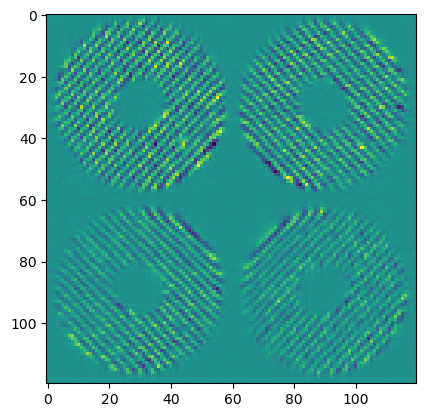

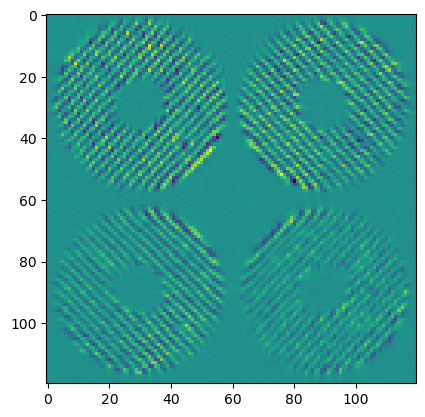

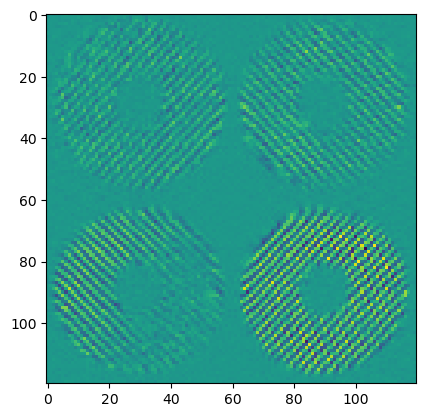

In [13]:
# double check this PCA basis looks good
import matplotlib.pyplot as plt

for i in range(3):
    plt.imshow(test_calib.ref_pca[:,i].reshape(120,120))
    plt.show()
